In [4]:
from langgraph.graph import StateGraph,START,END

In [ ]:
from typing import TypedDict

class bmi(TypedDict):
    weight: float
    hight:float
    bmi:float
    category:str



In [ ]:
def bmic(state:bmi):

    weight=state['weight']
    hight=state['hight']
    bmis=weight/(hight**2)
    state['bmi']=round(bmis,2)
    return state

def category(state:bmi):
    
    bmi=state['bmi']
    if bmi<=18:
        state['category']='underweight'
    elif 18<bmi<25:
        state['category']='normal'
    else:
        state['category']='overweight'
    return state

In [ ]:
graph=StateGraph(bmi)

#defining node 

graph.add_node('bmicalculator',bmic)
graph.add_node('category',category)

#defining edge 

graph.add_edge(START,'bmicalculator')
graph.add_edge('bmicalculator','category')
graph.add_edge('category',END)

workflow=graph.compile()

intial_state={'weight':80,'hight':1.73}
final_state=workflow.invoke(intial_state)

print(final_state)

{'weight': 80, 'hight': 1.73, 'bmi': 26.73, 'category': 'overweight'}


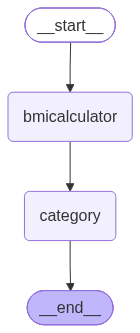

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
